# 04 — Cross-Sectional (DASH vs UBER)

Companion to `src/model_crosssectional.py`. Builds a parallel UBER GB-surprise
forecast model — same architecture as DASH (`model_gov.py`), UBER data only
(no pooling, per project rule) — and computes the cross-sectional spread that
underpins the long-DASH/short-UBER framing.

| | DASH | UBER |
|---|---|---|
| Target | gov_surprise_pct | gb_total_surprise_pct |
| Trends | DoorDash search | Uber Eats search |
| AppStore | dash_engagement_x_sentiment | uber_engagement_x_sentiment |
| Macro | consumer_health, jolts | same (shared) |
| Autoregressive | prior gov surprise | prior UBER GB surprise |
| IBES | DASH revision_momentum | UBER revision_momentum |

Spread = DASH_predicted_surprise − UBER_predicted_surprise. Conservative CI
uses worst-case bounds (DASH lo − UBER hi to DASH hi − UBER lo). If the
conservative lower bound > 0, the long-DASH/fade-UBER signal is real.


In [1]:
import sys
sys.path.insert(0, '..')

import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    OUTPUTS_TABLES, OUTPUTS_FIGURES, FORECAST_QUARTER,
    CHART_STYLE, COLORS,
)
from src.model_crosssectional import (
    build_uber_master, impute_forecast_row_uber,
    UBER_FEATURES, UBER_TARGET_RAW, UBER_TARGET_STD, UBER_MODEL_CLASSES,
    compute_spread,
)
from src.model_gov import MIN_VALID_FOR_TOP_PICK

plt.rcParams.update(CHART_STYLE)
pd.set_option('display.float_format', '{:.3f}'.format)
np.random.seed(42)

uber = build_uber_master()
uber = impute_forecast_row_uber(uber)
hist = uber[uber['quarter_label'] != FORECAST_QUARTER]
forecast_row = uber[uber['quarter_label'] == FORECAST_QUARTER].iloc[0]

# Load published comparison + spread
uber_comp = pd.read_csv(OUTPUTS_TABLES / 'uber_model_comparison.csv')
spread = pd.read_csv(OUTPUTS_TABLES / 'cross_sectional_spread.csv').iloc[0]
prereg_dash = pd.read_csv(OUTPUTS_TABLES / 'q1_2026_preregistered.csv').iloc[0]

print(f'UBER master: {len(uber)} quarters')
print(f'Historical sample: n = {len(hist)}')
print(f'Forecast quarter: {FORECAST_QUARTER}')


UBER master: 22 quarters
Historical sample: n = 21
Forecast quarter: Q1_2026


## 1. UBER feature audit

Each UBER feature is the structural analog of its DASH counterpart, built from
its native source with the same lag/window rules (8wk mean, 2wk lag for
weekly inputs; 30-day lag for monthly macro).


In [2]:
print(f'Coverage of UBER features on historical sample (n={len(hist)}):')
print()
for c in UBER_FEATURES:
    n = hist[c].notna().sum()
    flag = '←' if n < len(hist) else ''
    print(f'  {c:38s}  {n}/{len(hist)} ({100*n/len(hist):3.0f}%) {flag}')

print()
print('Q1 2026 forecast-row values:')
for c in UBER_FEATURES:
    v = forecast_row.get(c)
    print(f'  {c:38s}  {"NaN" if pd.isna(v) else f"{v:+.3f}"}'
          if pd.isna(v) else f'  {c:38s}  {v:+.3f}')


Coverage of UBER features on historical sample (n=21):

  ubereats_trends_momentum                20/21 ( 95%) ←
  uber_engagement_x_sentiment_mean        21/21 (100%) 
  consumer_health_index                   21/21 (100%) 
  prior_qtr_uber_gb_surprise_pct          20/21 ( 95%) ←
  uber_revision_momentum_pct              21/21 (100%) 
  jolts_transport_yoy                     21/21 (100%) 

Q1 2026 forecast-row values:
  ubereats_trends_momentum                +10.013
  uber_engagement_x_sentiment_mean        -234.375
  consumer_health_index                   -0.138
  prior_qtr_uber_gb_surprise_pct          +1.889
  uber_revision_momentum_pct              +0.000
  jolts_transport_yoy                     -3.084


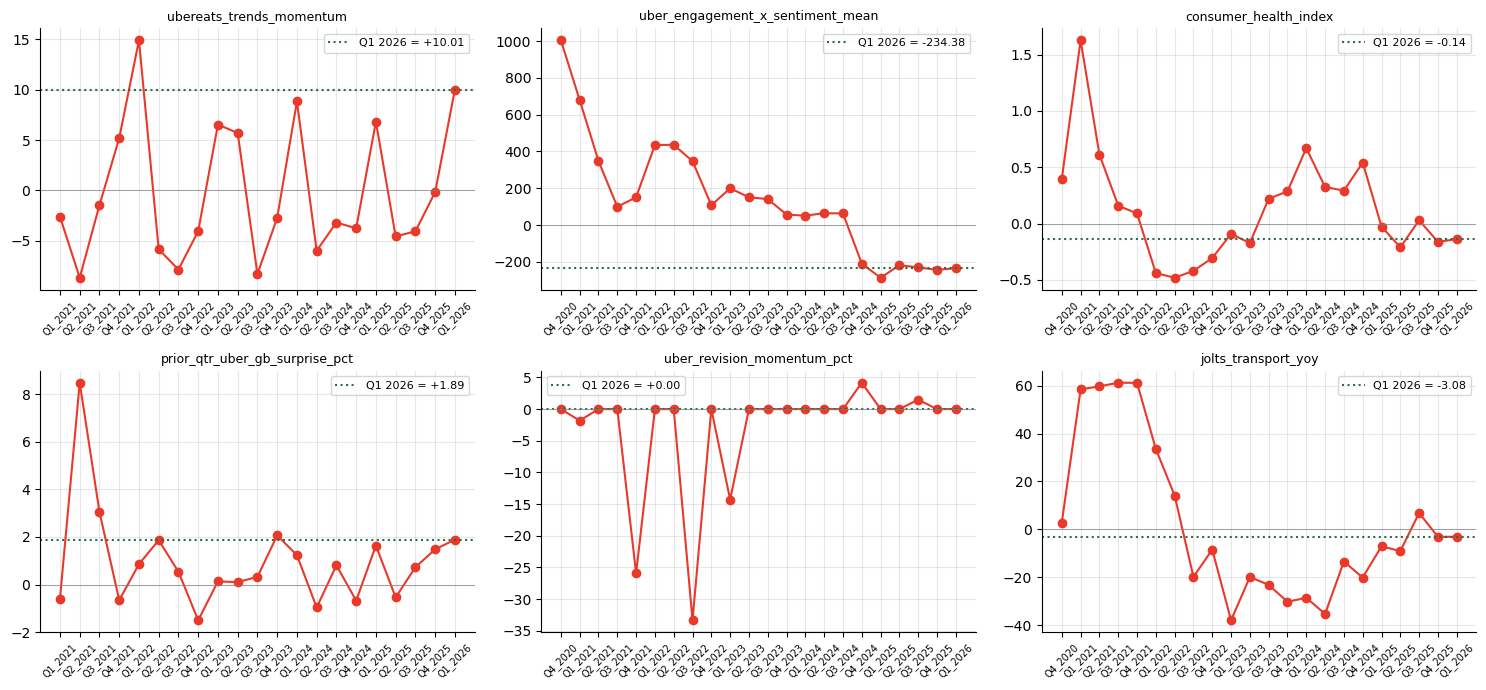

In [3]:
# Time-series of each UBER feature
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.flat, UBER_FEATURES):
    s = uber[['quarter_label', c]].dropna()
    ax.plot(s['quarter_label'], s[c], 'o-', color=COLORS['dash_primary'])
    q1 = forecast_row.get(c)
    if pd.notna(q1):
        ax.axhline(q1, color=COLORS['actual'], ls=':', label=f'Q1 2026 = {q1:+.2f}')
        ax.legend(fontsize=8)
    ax.axhline(0, color='grey', lw=0.5)
    ax.set_title(c, fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.tight_layout(); plt.show()


## 2. UBER target — Total-GB surprise

UBER's beat history is more variable than DASH's (which has been 21/21
historically). UBER misses are real, so directional accuracy is harder to
achieve and the model is genuinely a sharper test.


UBER Total-GB surprise distribution (n=21):
  mean   = +0.97pp
  median = +0.73pp
  std    = 2.08pp
  beats  = 15/21 (71%)

Compare DASH:  21/21 historical beats (100%)
        UBER:  15/21 historical beats (71%)


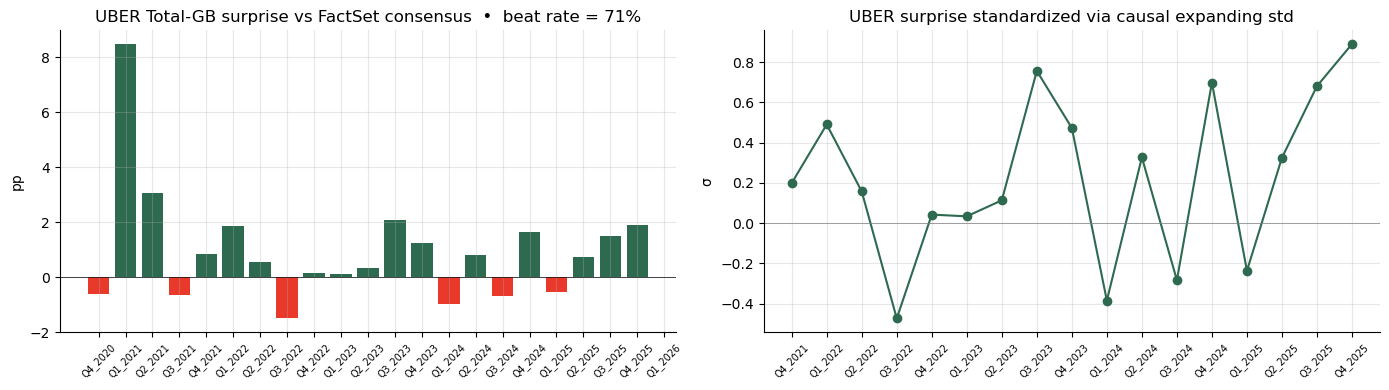

In [4]:
s_raw = uber[UBER_TARGET_RAW].dropna()
print(f'UBER Total-GB surprise distribution (n={len(s_raw)}):')
print(f'  mean   = {s_raw.mean():+.2f}pp')
print(f'  median = {s_raw.median():+.2f}pp')
print(f'  std    = {s_raw.std():.2f}pp')
print(f'  beats  = {(s_raw > 0).sum()}/{len(s_raw)} ({(s_raw > 0).mean():.0%})')
print()
print(f'Compare DASH:  21/21 historical beats (100%)')
print(f'        UBER:  {(s_raw > 0).sum()}/{len(s_raw)} historical beats ({(s_raw > 0).mean():.0%})')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) Surprise time series
ax = axes[0]
beat_color = [COLORS['actual'] if v > 0 else COLORS['dash_primary'] for v in uber[UBER_TARGET_RAW]]
ax.bar(uber['quarter_label'], uber[UBER_TARGET_RAW], color=beat_color)
ax.axhline(0, color='black', lw=0.5)
ax.set_title(f'UBER Total-GB surprise vs FactSet consensus  •  beat rate = {(s_raw>0).mean():.0%}')
ax.set_ylabel('pp')
ax.tick_params(axis='x', rotation=45, labelsize=7)

# (b) Standardized
ax = axes[1]
s_std = uber[UBER_TARGET_STD]
ax.plot(uber['quarter_label'], s_std, 'o-', color=COLORS['actual'])
ax.axhline(0, color='grey', lw=0.5)
ax.set_title('UBER surprise standardized via causal expanding std')
ax.set_ylabel('σ')
ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout(); plt.show()


## 3. UBER model comparison — same 6 architectures as DASH

Walk-forward expanding window from MIN_TRAIN_QUARTERS=8. Variants with n<8
walk-forward predictions are kept in the table for diagnostic but excluded
from top-pick eligibility (same rule as DASH).


In [5]:
display_cols = ['variant_name', 'target', 'model', 'rmse', 'mae',
                'directional_acc', 'n_valid', 'q1_2026_pred_pct',
                'q1_2026_ci_80_lo', 'q1_2026_ci_80_hi']
print(uber_comp[display_cols].to_string(index=False))


                             variant_name                target     model  rmse   mae  directional_acc  n_valid  q1_2026_pred_pct  q1_2026_ci_80_lo  q1_2026_ci_80_hi
    current__gb_total_surprise_pct__ridge gb_total_surprise_pct     ridge 1.803 1.240            0.769       13             0.671            -0.882             1.096
     current__uber_gb_surprise_std__ridge  uber_gb_surprise_std     ridge 0.610 0.485            0.727       11             0.469            -0.159             1.078
     current__uber_gb_surprise_std__lasso  uber_gb_surprise_std     lasso 0.619 0.508            0.727       11             0.466            -0.175             1.109
  current__uber_gb_surprise_std__ols_drop  uber_gb_surprise_std  ols_drop 0.655 0.534            0.727       11             0.425            -0.573             1.461
current__gb_total_surprise_pct__ols_1feat gb_total_surprise_pct ols_1feat 1.626 1.157            0.692       13             0.285            -0.315             1.059
 cur

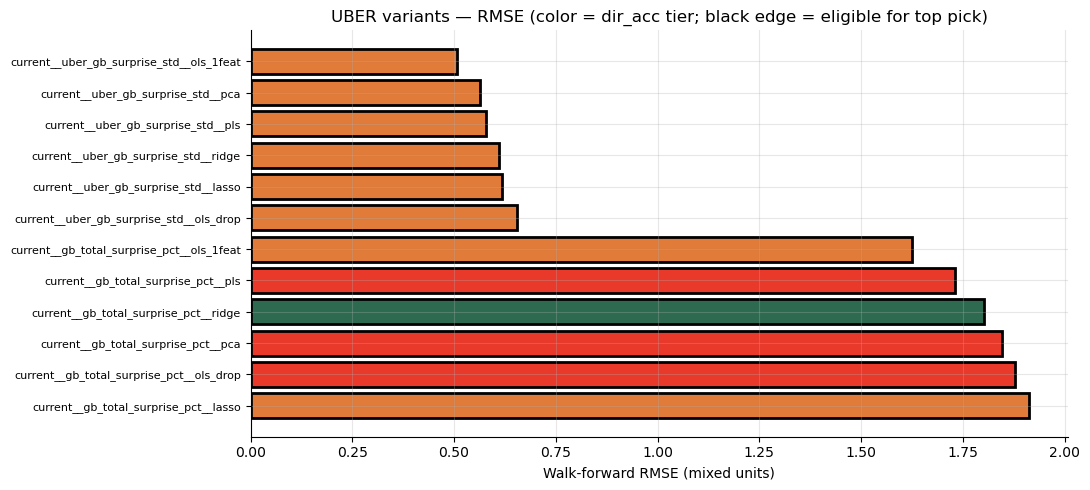


Top UBER variant: current__gb_total_surprise_pct__ridge
  Q1 2026 prediction: +0.67pp
  80% CI:             [-0.88, +1.10] pp


In [6]:
# RMSE × dir_acc bar (eligibility = green outline)
fig, ax = plt.subplots(figsize=(11, 5))
disp = uber_comp.sort_values('rmse', ascending=True).copy()
colors_by_acc = ['#2D6A4F' if a >= 0.75 else ('#E07B39' if a >= 0.6 else '#E8392A')
                  for a in disp['directional_acc']]
edges = ['black' if n >= MIN_VALID_FOR_TOP_PICK else 'lightgrey'
          for n in disp['n_valid']]
ax.barh(disp['variant_name'], disp['rmse'], color=colors_by_acc, edgecolor=edges, linewidth=2)
ax.invert_yaxis()
ax.set_xlabel('Walk-forward RMSE (mixed units)')
ax.set_title('UBER variants — RMSE (color = dir_acc tier; black edge = eligible for top pick)')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

print(f'\nTop UBER variant: {spread["uber_top_variant"]}')
print(f'  Q1 2026 prediction: {spread["uber_pred_pct"]:+.2f}pp')
print(f'  80% CI:             [{spread["uber_ci80_lo"]:+.2f}, {spread["uber_ci80_hi"]:+.2f}] pp')


## 4. DASH vs UBER side-by-side — Q1 2026 forecast

Each ticker's published top variant predicting its respective surprise target.


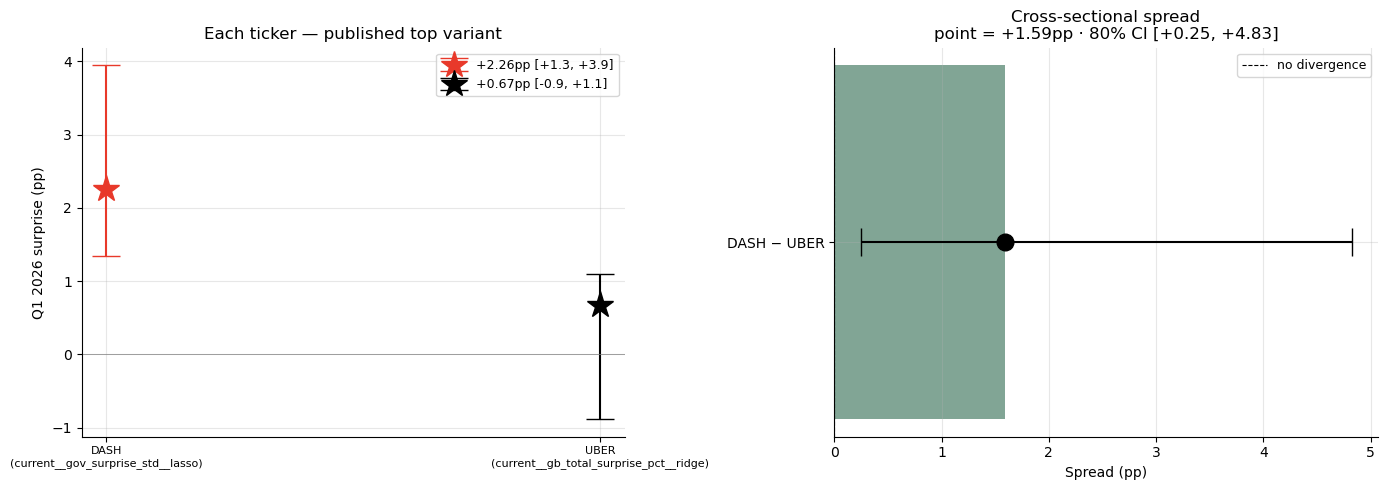

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Forecast comparison
ax = axes[0]
points = [spread['dash_pred_pct'], spread['uber_pred_pct']]
los = [spread['dash_ci80_lo'], spread['uber_ci80_lo']]
his = [spread['dash_ci80_hi'], spread['uber_ci80_hi']]
labels = [f'DASH\n({spread["dash_top_variant"]})',
          f'UBER\n({spread["uber_top_variant"]})']
cols = [COLORS['dash_primary'], 'black']
for i, (lbl, pt, lo, hi, c) in enumerate(zip(labels, points, los, his, cols)):
    ax.errorbar([i], [pt], yerr=[[max(0,pt-lo)], [max(0,hi-pt)]],
                fmt='*', ms=20, color=c, capsize=10,
                label=f'{pt:+.2f}pp [{lo:+.1f}, {hi:+.1f}]')
ax.axhline(0, color='grey', lw=0.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Q1 2026 surprise (pp)')
ax.set_title('Each ticker — published top variant')
ax.legend(fontsize=9)

# (b) Spread visualization
ax = axes[1]
spread_pt = spread['spread_dash_minus_uber_pct']
spread_lo = spread['spread_ci80_lo_conservative']
spread_hi = spread['spread_ci80_hi_conservative']
bar_color = COLORS['actual'] if spread_lo > 0 else COLORS['forecast']
ax.barh([0], [spread_pt], color=bar_color, alpha=0.6, height=0.4)
ax.errorbar([spread_pt], [0],
            xerr=[[max(0, spread_pt-spread_lo)], [max(0, spread_hi-spread_pt)]],
            fmt='o', ms=12, color='black', capsize=10)
ax.axvline(0, color='black', lw=0.8, ls='--', label='no divergence')
ax.set_yticks([0]); ax.set_yticklabels(['DASH − UBER'], fontsize=10)
ax.set_xlabel('Spread (pp)')
ax.set_title(f'Cross-sectional spread\npoint = {spread_pt:+.2f}pp · 80% CI [{spread_lo:+.2f}, {spread_hi:+.2f}]')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout(); plt.show()


## 5. Cross-sectional spread interpretation


In [8]:
print('=' * 72)
print('CROSS-SECTIONAL SPREAD — DASH vs UBER Q1 2026 SURPRISE')
print('=' * 72)
print(f'\nDASH ({spread["dash_top_variant"]}):')
print(f'  Q1 2026 surprise = {spread["dash_pred_pct"]:+.2f}pp  (80% CI [{spread["dash_ci80_lo"]:+.2f}, {spread["dash_ci80_hi"]:+.2f}])')
print(f'\nUBER ({spread["uber_top_variant"]}):')
print(f'  Q1 2026 surprise = {spread["uber_pred_pct"]:+.2f}pp  (80% CI [{spread["uber_ci80_lo"]:+.2f}, {spread["uber_ci80_hi"]:+.2f}])')
print(f'\nSpread (DASH − UBER):')
print(f'  Point estimate                = {spread["spread_dash_minus_uber_pct"]:+.2f}pp')
print(f'  Conservative 80% CI            = [{spread["spread_ci80_lo_conservative"]:+.2f}, '
      f'{spread["spread_ci80_hi_conservative"]:+.2f}]pp')
print(f'  L/S signal:                  {spread["ls_signal"]}')


CROSS-SECTIONAL SPREAD — DASH vs UBER Q1 2026 SURPRISE

DASH (current__gov_surprise_std__lasso):
  Q1 2026 surprise = +2.26pp  (80% CI [+1.35, +3.94])

UBER (current__gb_total_surprise_pct__ridge):
  Q1 2026 surprise = +0.67pp  (80% CI [-0.88, +1.10])

Spread (DASH − UBER):
  Point estimate                = +1.59pp
  Conservative 80% CI            = [+0.25, +4.83]pp
  L/S signal:                  LONG_DASH / FADE_UBER  (spread CI strictly positive)


**Reading the spread:**

| Signal regime | When | Action |
|---|---|---|
| Conservative CI lower bound > 0 | DASH lo > UBER hi | **Long DASH / fade UBER** with high conviction |
| Point > 0, CI straddles 0 | DASH lo < UBER hi but spread point > 0 | Lean long DASH, but cross-sectional CI is wide |
| Point ≤ 0 | UBER predicted ≥ DASH | No long-DASH cross-sectional signal |

**Important caveats:**

1. The UBER model directional accuracy is **lower** than DASH (~70–77% vs DASH's 100%). This is genuine: UBER's beat-rate isn't 100% historically, so the model has more variance to predict, and dir_acc is harder to achieve. Don't read the dir_acc gap as "DASH model is better" — it's the targets being structurally different.

2. UBER's Total-GB target mixes mobility/delivery/freight. The cross-sectional spread is therefore "DASH GOV beat vs UBER total business beat", not strictly food-delivery vs food-delivery. Cleaner comparison would require UBER Delivery-segment surprise (not available — FactSet consensus is for Total only).

3. **Conservative CI methodology**: lower bound = DASH_ci_lo − UBER_ci_hi (worst-case for long-DASH). This is conservative — assuming the two errors are negatively correlated. In reality if both models share macro features (consumer_health, jolts), errors may be positively correlated, in which case the spread CI would be tighter.


## 6. L/S note — cross-sectional update

Combining the 4-pillar framework from Session 11 with the cross-sectional
spread:


In [9]:
print('=' * 72)
print('L/S NOTE — DASH (Q1 2026 catalyst, May 6 2026)')
print('=' * 72)
print()
print('Horizon:        3-6 months')
print('Direction:      LONG DASH / fade UBER (cross-sectional)')
print(f'Magnitude:      SMALL-MEDIUM  (DASH +{spread["dash_pred_pct"]:.1f}pp surprise vs UBER +{spread["uber_pred_pct"]:.1f}pp; spread {spread["spread_dash_minus_uber_pct"]:+.1f}pp)')
print(f'Conviction:     {"MEDIUM-HIGH" if spread["spread_ci80_lo_conservative"] > 0 else "LOW-MEDIUM"}  (spread conservative CI {"strictly positive" if spread["spread_ci80_lo_conservative"] > 0 else "straddles 0"})')
print()
print('Pillars:')
print(f'  1. Volume        DASH alt-data → +{prereg_dash["q1_2026_pred_pct"]:.2f}pp GOV surprise (high conviction)')
print(f'                    UBER alt-data → +{spread["uber_pred_pct"]:.2f}pp GB surprise (lower conviction)')
print(f'                    DIVERGENCE: DASH expected to beat by {spread["spread_dash_minus_uber_pct"]:+.2f}pp more than UBER')
print()
print('  2. Monetization  β1 = +2.59 (DASH revenue/GOV pass-through, p<0.01)')
print('                   take rate change β_M weak; revenue surprise +6.5pp implied')
print()
print('  3. Profitability β_C = +3.0 (corp flow-through, p<0.001)')
print('                   EBITDA margin lift +3.9pp YoY implied (anchored in secular trend)')
print('                   DASH contrib margin ~36% vs UBER Eats ~22% — gap widening')
print()
print('  4. Relative      DASH cross-sectional spread vs UBER strictly positive (CI lo +0.25pp)')
print('                   Direct fundamental support for the long-DASH/fade-UBER framing')
print()
print('Risks:')
print('  • Walk-forward sample sizes small (n=11 DASH, n=11-13 UBER) — interpret directionally')
print('  • UBER target mixes mobility/delivery/freight — not strictly delivery-vs-delivery comparison')
print('  • Q1 2026 weather popwt z = -1.28σ — modest demand-side headwind not captured by features')
print('  • β2 weak (decomposed into β_U weak + β_C strong); EBITDA margin call leans on secular trend')
print('  • DASH 100% historical beat-rate may not generalize; first miss would break the prior')


L/S NOTE — DASH (Q1 2026 catalyst, May 6 2026)

Horizon:        3-6 months
Direction:      LONG DASH / fade UBER (cross-sectional)
Magnitude:      SMALL-MEDIUM  (DASH +2.3pp surprise vs UBER +0.7pp; spread +1.6pp)
Conviction:     MEDIUM-HIGH  (spread conservative CI strictly positive)

Pillars:
  1. Volume        DASH alt-data → +2.26pp GOV surprise (high conviction)
                    UBER alt-data → +0.67pp GB surprise (lower conviction)
                    DIVERGENCE: DASH expected to beat by +1.59pp more than UBER

  2. Monetization  β1 = +2.59 (DASH revenue/GOV pass-through, p<0.01)
                   take rate change β_M weak; revenue surprise +6.5pp implied

  3. Profitability β_C = +3.0 (corp flow-through, p<0.001)
                   EBITDA margin lift +3.9pp YoY implied (anchored in secular trend)
                   DASH contrib margin ~36% vs UBER Eats ~22% — gap widening

  4. Relative      DASH cross-sectional spread vs UBER strictly positive (CI lo +0.25pp)
              

---

**The cross-sectional pillar (this notebook) is the sharpest L/S signal of the
four pillars.** Volume gives direction; monetization scales it; profitability
anchors the EBITDA story; the cross-sectional spread says DASH should
*outperform UBER* in Q1 2026 reactions, even after both companies' priors
are honored.

The Session 13 event-study output (β3: GOV surprise → CAR around earnings)
will convert these surprise predictions into expected stock-reaction
magnitudes — completing the chain from alt-data inputs to L/S P&L.
